# Driver Risk Classification Model
## Anomaly Detection for Risky Driver Behavior

This notebook implements a machine learning approach to classify drivers based on risk levels using vehicle sensor data. We use **Isolation Forest** and **One-Class SVM** for anomaly detection, combined with feature engineering from 5-second time windows.

**Dataset:** 10 drivers (A-J) with vehicle telemetry data including speed, acceleration, throttle, braking, and steering metrics.

**Approach:**
1. Feature extraction from 5-second time windows
2. Risk scoring based on driving behavior patterns  
3. Anomaly detection to identify risky vs safe driving segments
4. Driver-level risk classification

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, zscore
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

## 1. Data Loading and Exploration

In [10]:
df = pd.read_csv('../cleaned_data.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nDrivers: {sorted(df['driver_id'].unique())}")
print(f"\nSamples per driver:")
print(df['driver_id'].value_counts().sort_index())

Dataset shape: (94380, 31)

Drivers: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J']

Samples per driver:
driver_id
A     7240
B    12864
C     7500
D    13244
E     8436
F    11012
G     7492
H     9880
I     7808
J     8904
Name: count, dtype: int64


In [11]:
df.head(10)

,fuel_consumption,accelerator_pedal_value,throttle_position_signal,intake_air_pressure,absolute_throttle_position,engine_in_fuel_cut_off,engine_speed,engine_torque_after_correction,torque_of_friction,flywheel_torque_after_torque_interventions,...,acceleration_speed_longitudinal,indication_of_brake_switch_on_off,master_cylinder_pressure,calculated_road_gradient,acceleration_speed_lateral,steering_wheel_speed,steering_wheel_angle,time_s,driver_id,pathorder
0,268.8,0.0,5.2,33,13.3,0,929,5.5,9.0,-5.9,...,-8.5,1,325.5,0.0,-8.8,0,-3.4,1,A,1
1,243.2,0.0,6.1,40,13.7,0,726,7.0,7.8,1.7,...,0.1,1,0.9,0.0,-0.2,0,-3.6,2,A,1
2,217.6,0.0,5.2,41,13.7,0,685,7.0,7.4,-3.0,...,0.1,1,0.9,0.0,-0.2,0,-3.6,3,A,1
3,204.8,0.0,4.7,38,13.3,0,675,7.0,6.6,-1.3,...,0.1,1,0.9,0.0,-0.2,0,-3.6,4,A,1
4,217.6,0.0,5.7,40,13.7,0,716,8.2,11.3,-15.6,...,0.1,1,0.9,0.0,-0.2,0,-3.5,5,A,1
5,243.2,0.0,5.7,41,13.7,0,740,9.0,16.0,-16.9,...,0.0,2,36.7,0.0,-0.2,0,-3.4,6,A,1
6,217.6,0.0,5.7,42,13.7,0,682,11.7,16.4,-10.8,...,0.0,2,61.8,0.0,-0.2,0,-3.6,7,A,1
7,294.4,0.0,6.6,52,14.5,0,670,16.8,18.0,1.3,...,0.0,2,38.9,0.0,-0.2,0,-1.6,8,A,1
8,332.8,0.0,7.1,60,14.5,0,655,21.5,18.8,8.5,...,0.0,2,12.5,0.0,-0.2,8,7.9,9,A,1
9,358.4,0.0,7.1,65,14.9,0,648,23.8,19.5,12.2,...,-0.1,2,1.8,0.0,-0.2,0,7.7,10,A,1


## 2. Feature Engineering with 5-Second Time Windows

We aggregate raw sensor data into 5-second windows, extracting statistical features that capture driving behavior patterns.

In [12]:
RISK_FEATURES = [
    'vehicle_speed',
    'acceleration_speed_longitudinal',
    'acceleration_speed_lateral', 
    'engine_speed',
    'throttle_position_signal',
    'accelerator_pedal_value',
    'master_cylinder_pressure',
    'steering_wheel_speed',
    'steering_wheel_angle',
    'fuel_consumption',
    'indication_of_brake_switch_on_off'
]

available_features = [f for f in RISK_FEATURES if f in df.columns]
print(f"Using {len(available_features)} features for analysis:")
for f in available_features:
    print(f"  - {f}")

Using 11 features for analysis:
  - vehicle_speed
  - acceleration_speed_longitudinal
  - acceleration_speed_lateral
  - engine_speed
  - throttle_position_signal
  - accelerator_pedal_value
  - master_cylinder_pressure
  - steering_wheel_speed
  - steering_wheel_angle
  - fuel_consumption
  - indication_of_brake_switch_on_off


In [13]:
def extract_window_features(window_df, features):
    """
    Extract statistical features from a 5-second time window.
    Returns features that characterize driving behavior.
    """
    stats = {}
    
    for feat in features:
        if feat not in window_df.columns:
            continue
        col = window_df[feat].dropna()
        if len(col) == 0:
            continue
            
        stats[f'{feat}_mean'] = col.mean()
        stats[f'{feat}_std'] = col.std() if len(col) > 1 else 0
        stats[f'{feat}_max'] = col.max()
        stats[f'{feat}_min'] = col.min()
        stats[f'{feat}_range'] = col.max() - col.min()
        
        if len(col) > 2:
            stats[f'{feat}_skew'] = skew(col)
        else:
            stats[f'{feat}_skew'] = 0
    
    return stats


def create_time_windows(df, window_size=5):
    """
    Aggregate data into time windows per driver.
    Window size in seconds (5s default).
    """
    all_windows = []
    
    for driver in df['driver_id'].unique():
        driver_data = df[df['driver_id'] == driver].copy()
        driver_data = driver_data.sort_values('time_s')
        
        max_time = driver_data['time_s'].max()
        window_id = 0
        
        for start_time in range(0, int(max_time), window_size):
            end_time = start_time + window_size
            window_data = driver_data[
                (driver_data['time_s'] >= start_time) & 
                (driver_data['time_s'] < end_time)
            ]
            
            if len(window_data) < 2:
                continue
            
            features = extract_window_features(window_data, available_features)
            features['driver_id'] = driver
            features['window_id'] = window_id
            features['window_start'] = start_time
            
            all_windows.append(features)
            window_id += 1
    
    return pd.DataFrame(all_windows)

windowed_df = create_time_windows(df, window_size=5)
print(f"Created {len(windowed_df)} time windows")
print(f"Windows per driver:")
print(windowed_df['driver_id'].value_counts().sort_index())

Created 4997 time windows
Windows per driver:
driver_id
A    406
B    511
C    404
D    527
E    556
F    587
G    408
H    575
I    433
J    590
Name: count, dtype: int64


## 3. Risk Score Calculation

We compute a risk score based on aggressive driving indicators:
- High speed variability
- Harsh acceleration/braking
- Aggressive steering
- High throttle usage

In [14]:
def calculate_risk_scores(df):
    """
    Calculate risk scores based on driving behavior indicators.
    Higher score = more risky driving.
    """
    df = df.copy()
    
    risk_indicators = {
        'speed_risk': 'vehicle_speed_std',
        'accel_risk': 'acceleration_speed_longitudinal_std',
        'lateral_risk': 'acceleration_speed_lateral_std',
        'brake_risk': 'master_cylinder_pressure_max',
        'steering_risk': 'steering_wheel_speed_std',
        'throttle_risk': 'accelerator_pedal_value_max'
    }
    
    scaler = RobustScaler()
    risk_cols = []
    
    for risk_name, col_name in risk_indicators.items():
        if col_name in df.columns:
            df[risk_name] = df[col_name].fillna(0)
            risk_cols.append(risk_name)
    
    if risk_cols:
        df[risk_cols] = scaler.fit_transform(df[risk_cols])
        df['risk_score'] = df[risk_cols].mean(axis=1)
        df['risk_score'] = (df['risk_score'] - df['risk_score'].min()) / \
                           (df['risk_score'].max() - df['risk_score'].min())
    
    return df

windowed_df = calculate_risk_scores(windowed_df)

print("Risk Score Distribution:")
print(windowed_df['risk_score'].describe())

Risk Score Distribution:
count    4997.000000
mean        0.118019
std         0.071519
min         0.000000
25%         0.080691
50%         0.104676
75%         0.138287
max         1.000000
Name: risk_score, dtype: float64


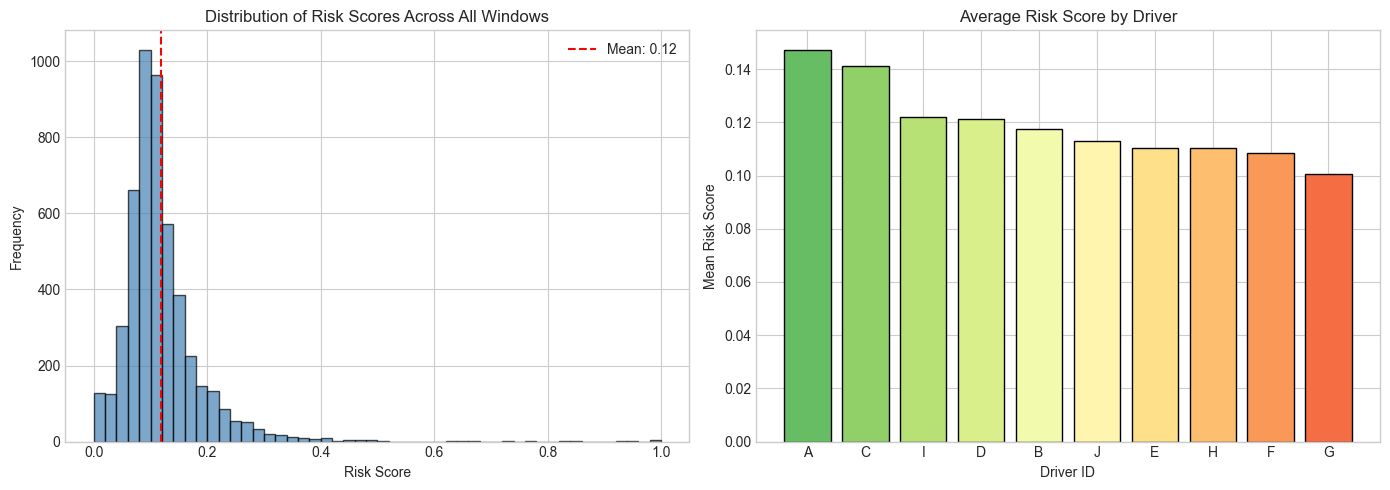

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(windowed_df['risk_score'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('Risk Score')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Risk Scores Across All Windows')
axes[0].axvline(windowed_df['risk_score'].mean(), color='red', linestyle='--', label=f"Mean: {windowed_df['risk_score'].mean():.2f}")
axes[0].legend()

driver_risk = windowed_df.groupby('driver_id')['risk_score'].mean().sort_values(ascending=False)
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(driver_risk)))
axes[1].bar(driver_risk.index, driver_risk.values, color=colors, edgecolor='black')
axes[1].set_xlabel('Driver ID')
axes[1].set_ylabel('Mean Risk Score')
axes[1].set_title('Average Risk Score by Driver')

plt.tight_layout()
plt.show()

## 4. Anomaly Detection Models

We use two complementary approaches:
1. **Isolation Forest** - Tree-based anomaly detection
2. **One-Class SVM** - Boundary-based detection

Anomalies represent risky/aggressive driving patterns.

In [16]:
feature_cols = [col for col in windowed_df.columns 
                if col not in ['driver_id', 'window_id', 'window_start', 'risk_score',
                              'speed_risk', 'accel_risk', 'lateral_risk', 
                              'brake_risk', 'steering_risk', 'throttle_risk']]

X = windowed_df[feature_cols].fillna(0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Feature matrix shape: {X_scaled.shape}")

Feature matrix shape: (4997, 66)


In [17]:
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.15,
    random_state=42,
    n_jobs=-1
)

windowed_df['iso_anomaly'] = iso_forest.fit_predict(X_scaled)
windowed_df['iso_score'] = iso_forest.decision_function(X_scaled)

windowed_df['iso_label'] = windowed_df['iso_anomaly'].map({1: 'Normal', -1: 'Risky'})

print("Isolation Forest Results:")
print(windowed_df['iso_label'].value_counts())
print(f"\nAnomaly rate: {(windowed_df['iso_anomaly'] == -1).mean()*100:.1f}%")

Isolation Forest Results:
iso_label
Normal    4247
Risky      750
Name: count, dtype: int64

Anomaly rate: 15.0%


In [18]:
oc_svm = OneClassSVM(
    kernel='rbf',
    gamma='scale',
    nu=0.15
)

windowed_df['svm_anomaly'] = oc_svm.fit_predict(X_scaled)
windowed_df['svm_score'] = oc_svm.decision_function(X_scaled)

windowed_df['svm_label'] = windowed_df['svm_anomaly'].map({1: 'Normal', -1: 'Risky'})

print("One-Class SVM Results:")
print(windowed_df['svm_label'].value_counts())
print(f"\nAnomaly rate: {(windowed_df['svm_anomaly'] == -1).mean()*100:.1f}%")

One-Class SVM Results:
svm_label
Normal    4245
Risky      752
Name: count, dtype: int64

Anomaly rate: 15.0%


In [19]:
windowed_df['ensemble_risky'] = ((windowed_df['iso_anomaly'] == -1) | 
                                  (windowed_df['svm_anomaly'] == -1)).astype(int)

windowed_df['consensus_risky'] = ((windowed_df['iso_anomaly'] == -1) & 
                                   (windowed_df['svm_anomaly'] == -1)).astype(int)

print("Ensemble (Either model flags as risky):")
print(f"  Risky windows: {windowed_df['ensemble_risky'].sum()} ({windowed_df['ensemble_risky'].mean()*100:.1f}%)")

print("\nConsensus (Both models agree on risky):")
print(f"  Risky windows: {windowed_df['consensus_risky'].sum()} ({windowed_df['consensus_risky'].mean()*100:.1f}%)")

Ensemble (Either model flags as risky):
  Risky windows: 929 (18.6%)

Consensus (Both models agree on risky):
  Risky windows: 573 (11.5%)


## 5. Driver Risk Classification

Classify each driver into risk levels based on their proportion of risky driving windows.

In [20]:
def classify_driver_risk(risky_ratio):
    """Classify driver into risk levels based on proportion of risky windows."""
    if risky_ratio >= 0.30:
        return 'High Risk'
    elif risky_ratio >= 0.15:
        return 'Medium Risk'  
    else:
        return 'Low Risk'

driver_summary = windowed_df.groupby('driver_id').agg({
    'risk_score': ['mean', 'std', 'max'],
    'iso_anomaly': lambda x: (x == -1).mean(),
    'svm_anomaly': lambda x: (x == -1).mean(),
    'consensus_risky': 'mean',
    'window_id': 'count'
}).round(3)

driver_summary.columns = ['risk_mean', 'risk_std', 'risk_max', 
                          'iso_risky_ratio', 'svm_risky_ratio', 
                          'consensus_risky_ratio', 'n_windows']

driver_summary['risk_level'] = driver_summary['consensus_risky_ratio'].apply(classify_driver_risk)

driver_summary = driver_summary.sort_values('risk_mean', ascending=False)
print("Driver Risk Summary:")
driver_summary

Driver Risk Summary:


,risk_mean,risk_std,risk_max,iso_risky_ratio,svm_risky_ratio,consensus_risky_ratio,n_windows,risk_level
driver_id,,,,,,,,
A,0.147,0.087,0.987,0.337,0.328,0.286,406,Medium Risk
C,0.141,0.065,0.466,0.200,0.213,0.158,404,Medium Risk
I,0.122,0.075,0.841,0.136,0.134,0.095,433,Low Risk
D,0.121,0.050,0.642,0.087,0.108,0.066,527,Low Risk
B,0.117,0.064,0.726,0.168,0.129,0.100,511,Low Risk
J,0.113,0.069,1.000,0.147,0.144,0.114,590,Low Risk
H,0.110,0.067,0.839,0.125,0.125,0.096,575,Low Risk
E,0.110,0.080,0.773,0.128,0.135,0.103,556,Low Risk
F,0.108,0.069,0.925,0.099,0.107,0.082,587,Low Risk


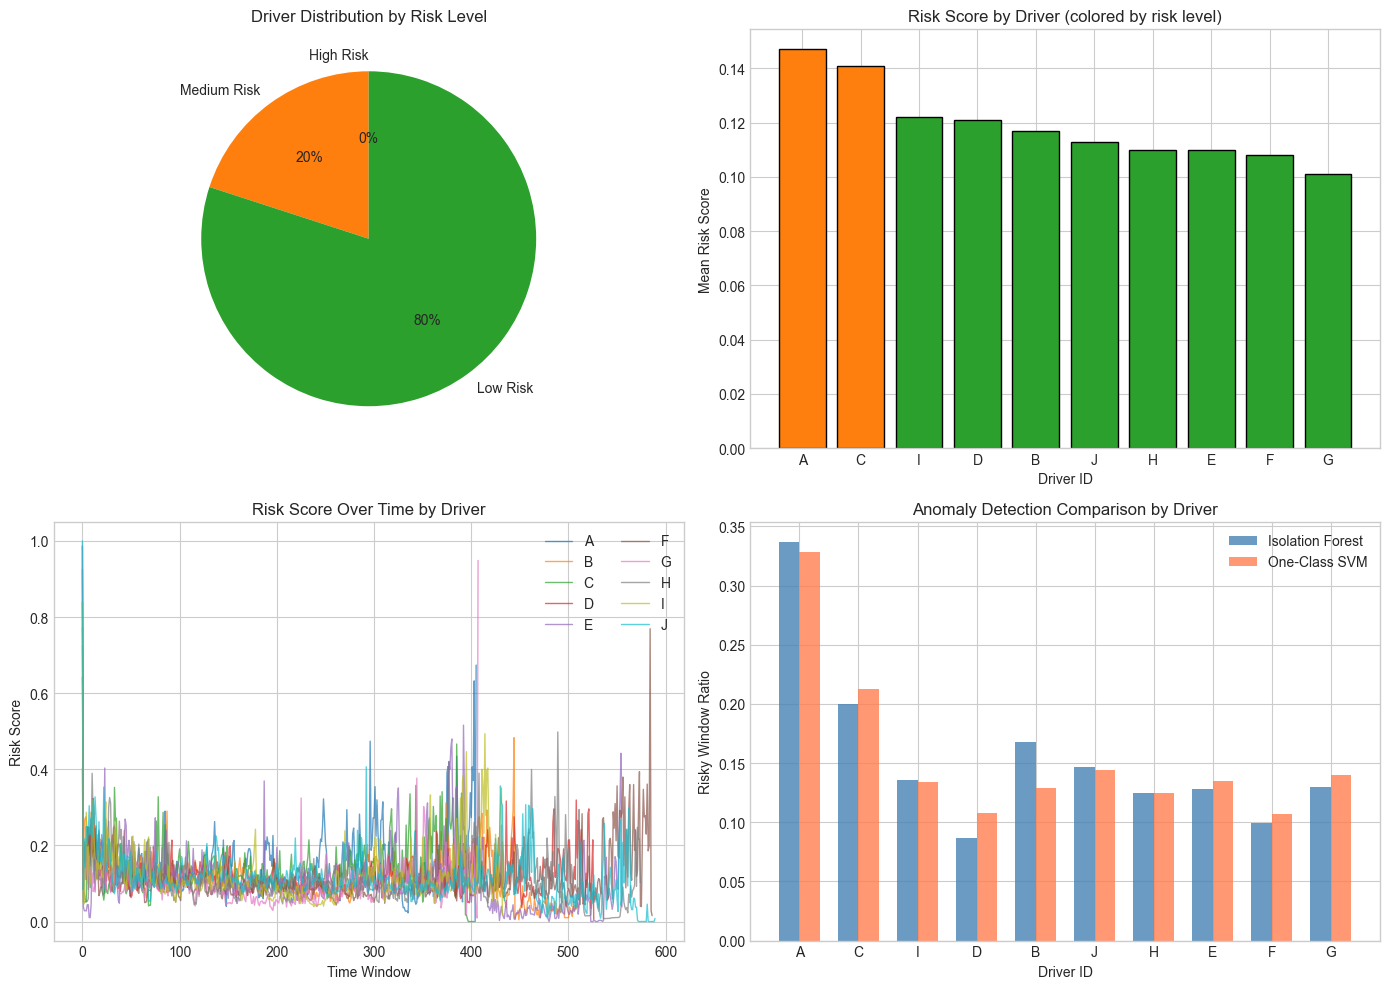

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

risk_order = ['High Risk', 'Medium Risk', 'Low Risk']
risk_colors = {'High Risk': '#d62728', 'Medium Risk': '#ff7f0e', 'Low Risk': '#2ca02c'}
level_counts = driver_summary['risk_level'].value_counts().reindex(risk_order, fill_value=0)
axes[0,0].pie(level_counts.values, labels=level_counts.index, autopct='%1.0f%%',
              colors=[risk_colors[l] for l in level_counts.index], startangle=90)
axes[0,0].set_title('Driver Distribution by Risk Level')

x = range(len(driver_summary))
colors = [risk_colors[level] for level in driver_summary['risk_level']]
axes[0,1].bar(x, driver_summary['risk_mean'], color=colors, edgecolor='black')
axes[0,1].set_xticks(x)
axes[0,1].set_xticklabels(driver_summary.index)
axes[0,1].set_xlabel('Driver ID')
axes[0,1].set_ylabel('Mean Risk Score')
axes[0,1].set_title('Risk Score by Driver (colored by risk level)')

for driver in sorted(windowed_df['driver_id'].unique()):
    driver_data = windowed_df[windowed_df['driver_id'] == driver]
    axes[1,0].plot(driver_data['window_id'], driver_data['risk_score'], 
                   alpha=0.7, label=driver, linewidth=1)
axes[1,0].set_xlabel('Time Window')
axes[1,0].set_ylabel('Risk Score')
axes[1,0].set_title('Risk Score Over Time by Driver')
axes[1,0].legend(loc='upper right', ncol=2)

metrics = ['iso_risky_ratio', 'svm_risky_ratio']
x_pos = np.arange(len(driver_summary))
width = 0.35
axes[1,1].bar(x_pos - width/2, driver_summary['iso_risky_ratio'], width, 
              label='Isolation Forest', color='steelblue', alpha=0.8)
axes[1,1].bar(x_pos + width/2, driver_summary['svm_risky_ratio'], width,
              label='One-Class SVM', color='coral', alpha=0.8)
axes[1,1].set_xticks(x_pos)
axes[1,1].set_xticklabels(driver_summary.index)
axes[1,1].set_xlabel('Driver ID')
axes[1,1].set_ylabel('Risky Window Ratio')
axes[1,1].set_title('Anomaly Detection Comparison by Driver')
axes[1,1].legend()

plt.tight_layout()
plt.show()

## 6. Detailed Risk Analysis - PCA Visualization

Explained variance: 36.1%


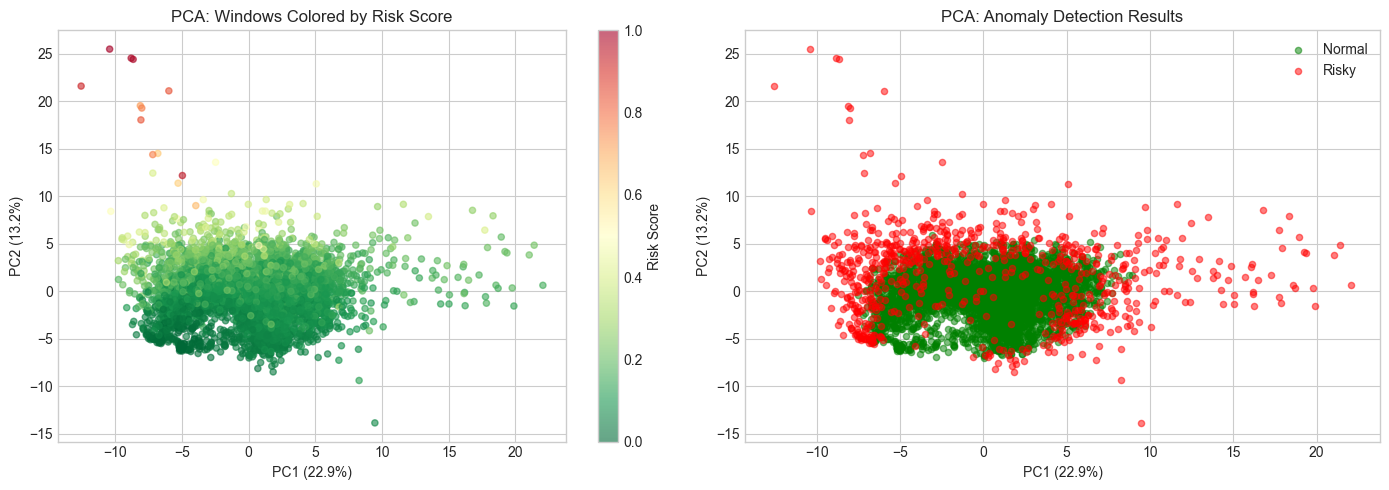

In [22]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"Explained variance: {pca.explained_variance_ratio_.sum()*100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

scatter = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], 
                          c=windowed_df['risk_score'], cmap='RdYlGn_r',
                          alpha=0.6, s=20)
plt.colorbar(scatter, ax=axes[0], label='Risk Score')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].set_title('PCA: Windows Colored by Risk Score')

colors = {'Normal': 'green', 'Risky': 'red'}
for label in ['Normal', 'Risky']:
    mask = windowed_df['iso_label'] == label
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], 
                   c=colors[label], label=label, alpha=0.5, s=20)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].set_title('PCA: Anomaly Detection Results')
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Feature Importance Analysis

Which driving behaviors contribute most to risk classification?

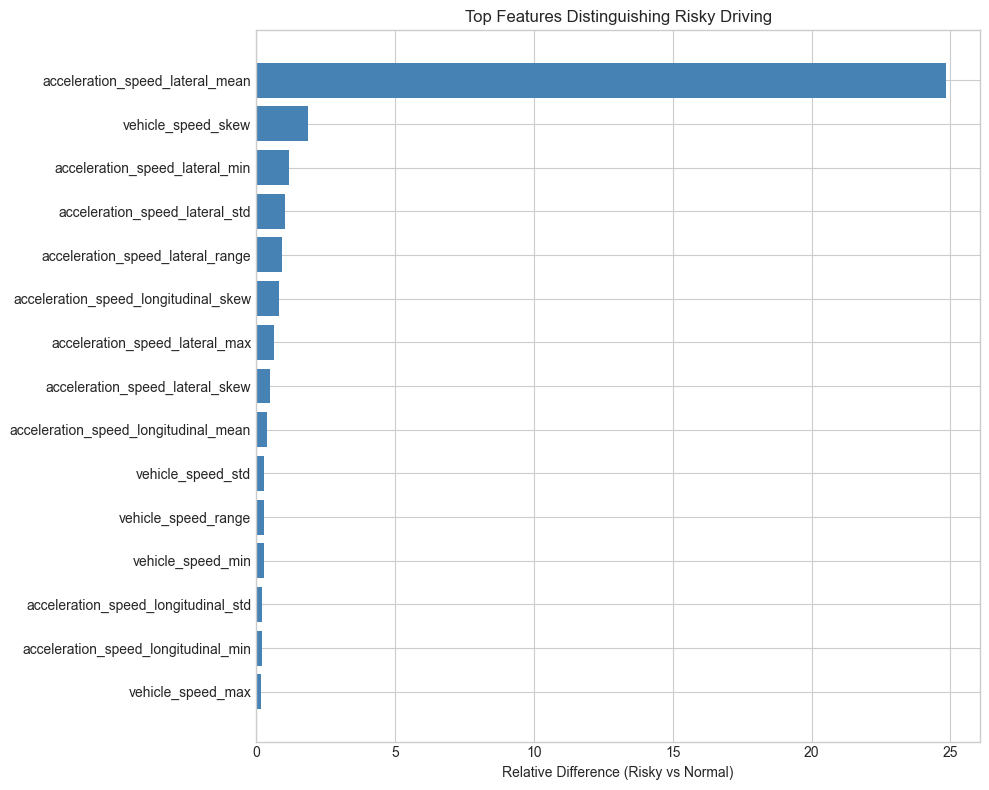

In [23]:
risky_windows = windowed_df[windowed_df['consensus_risky'] == 1]
normal_windows = windowed_df[windowed_df['consensus_risky'] == 0]

feature_importance = {}
for col in feature_cols[:20]:
    if col in windowed_df.columns:
        risky_mean = risky_windows[col].mean()
        normal_mean = normal_windows[col].mean()
        if normal_mean != 0:
            diff_ratio = abs(risky_mean - normal_mean) / (abs(normal_mean) + 1e-10)
            feature_importance[col] = diff_ratio

importance_df = pd.DataFrame({
    'feature': list(feature_importance.keys()),
    'importance': list(feature_importance.values())
}).sort_values('importance', ascending=True).tail(15)

plt.figure(figsize=(10, 8))
plt.barh(importance_df['feature'], importance_df['importance'], color='steelblue')
plt.xlabel('Relative Difference (Risky vs Normal)')
plt.title('Top Features Distinguishing Risky Driving')
plt.tight_layout()
plt.show()

## 8. Final Results Summary

In [24]:
print("="*60)
print("Driver Risk Classification Results")
print("="*60)

print("\nDataset overview")
print(f"   Total time windows analyzed: {len(windowed_df)}")
print(f"   Window size: 5 seconds")
print(f"   Number of drivers: {windowed_df['driver_id'].nunique()}")

print("\nHigh risk drivers:")
high_risk = driver_summary[driver_summary['risk_level'] == 'High Risk']
if len(high_risk) > 0:
    for driver in high_risk.index:
        print(f"   Driver {driver}: {high_risk.loc[driver, 'consensus_risky_ratio']*100:.1f}% risky windows")
else:
    print("   None")

print("\nMedium risk drivers:")
med_risk = driver_summary[driver_summary['risk_level'] == 'Medium Risk']
if len(med_risk) > 0:
    for driver in med_risk.index:
        print(f"   Driver {driver}: {med_risk.loc[driver, 'consensus_risky_ratio']*100:.1f}% risky windows")
else:
    print("   None")

print("\nLow risk drivers:")
low_risk = driver_summary[driver_summary['risk_level'] == 'Low Risk']
if len(low_risk) > 0:
    for driver in low_risk.index:
        print(f"   Driver {driver}: {low_risk.loc[driver, 'consensus_risky_ratio']*100:.1f}% risky windows")
else:
    print("   None")

print("\n" + "="*60)

Driver Risk Classification Results

Dataset overview
   Total time windows analyzed: 4997
   Window size: 5 seconds
   Number of drivers: 10

High risk drivers:
   None

Medium risk drivers:
   Driver A: 28.6% risky windows
   Driver C: 15.8% risky windows

Low risk drivers:
   Driver I: 9.5% risky windows
   Driver D: 6.6% risky windows
   Driver B: 10.0% risky windows
   Driver J: 11.4% risky windows
   Driver H: 9.6% risky windows
   Driver E: 10.3% risky windows
   Driver F: 8.2% risky windows
   Driver G: 9.6% risky windows



In [25]:
windowed_df.to_csv('driver_risk_analysis_results.csv', index=False)
driver_summary.to_csv('driver_risk_summary.csv')
print("Results saved to CSV files.")

Results saved to CSV files.
